# Olist Brazilian E-Commerce: data model exploration

This notebook profiles the Olist CSV dataset, proposes primary and foreign-key
relationships, produces a compact entity-relationship (ER) diagram, and offers
optional checks for an equivalent PostgreSQL database.

**Recommended order:** run the setup and data-loading sections first, then the
profiling, relationship, and diagram sections. The PostgreSQL section is optional
and requires a running database that has already been populated.


## 1. Setup

Install the Python packages once per environment. `graphviz` also needs the
Graphviz system application installed so that the `dot` command is available.


In [1]:
# Run this only if the packages are not already installed in the current kernel.
%pip install -q pandas sqlalchemy psycopg2-binary graphviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sqlalchemy import create_engine

In [3]:
from pathlib import Path
import os
import sys

import pandas as pd
from graphviz import Digraph
from IPython.display import Image, display

pd.set_option("display.max_columns", 100)

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")


Python executable: /Library/Developer/CommandLineTools/usr/bin/python3
Python version: 3.9.6


## 2. Locate and load the CSV files

The default points to the local KaggleHub cache. Set `OLIST_DATASET_PATH` before
starting Jupyter if the data lives elsewhere. The validation below fails early
with a clear message when the folder is unavailable.


In [4]:
DEFAULT_DATASET_PATH = Path(
    "/Users/ouahibaahmid/.cache/kagglehub/datasets/olistbr/"
    "brazilian-ecommerce/versions/2"
)
DATASET_PATH = Path(os.environ.get("OLIST_DATASET_PATH", DEFAULT_DATASET_PATH))

if not DATASET_PATH.is_dir():
    raise FileNotFoundError(
        f"Dataset directory was not found: {DATASET_PATH}\n"
        "Set the OLIST_DATASET_PATH environment variable to the CSV folder."
    )

csv_paths = sorted(DATASET_PATH.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No CSV files were found in {DATASET_PATH}")

print(f"Dataset path: {DATASET_PATH}")
print(f"Found {len(csv_paths)} CSV files:")
for path in csv_paths:
    print(f"- {path.name}")


Dataset path: /Users/ouahibaahmid/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2
Found 9 CSV files:
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_items_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_orders_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv
- product_category_name_translation.csv


In [5]:
# The file stem is retained as the table key so it stays traceable to the source CSV.
tables = {
    path.stem: pd.read_csv(path, low_memory=False)
    for path in csv_paths
}

dataset_summary = pd.DataFrame(
    [
        {"table": name, "rows": len(df), "columns": df.shape[1]}
        for name, df in tables.items()
    ]
).sort_values("table", ignore_index=True)

display(dataset_summary)


,table,rows,columns
0,olist_customers_dataset,99441,5
1,olist_geolocation_dataset,1000163,5
2,olist_order_items_dataset,112650,7
3,olist_order_payments_dataset,103886,5
4,olist_order_reviews_dataset,99224,7
5,olist_orders_dataset,99441,8
6,olist_products_dataset,32951,9
7,olist_sellers_dataset,3095,4
8,product_category_name_translation,71,2


## 3. Profile the source tables

This section gives a compact view of each table's columns, data types, missing
values, and distinct-value counts. It is an exploratory aid; a distinct column is
not automatically a business key without domain validation.


In [6]:
def profile_table(df: pd.DataFrame) -> pd.DataFrame:
    '''Return column-level completeness and cardinality information for one table.'''
    return pd.DataFrame(
        {
            "column": df.columns,
            "dtype": df.dtypes.astype(str).to_numpy(),
            "null_count": df.isna().sum().to_numpy(),
            "null_pct": (df.isna().mean().mul(100).round(2)).to_numpy(),
            "distinct_values": [df[column].nunique(dropna=True) for column in df.columns],
        }
    )


for table_name, df in tables.items():
    print(f"\n{'=' * 90}\n{table_name} — {len(df):,} rows × {df.shape[1]} columns")
    display(profile_table(df))



olist_customers_dataset — 99,441 rows × 5 columns


,column,dtype,null_count,null_pct,distinct_values
0,customer_id,object,0,0.0,99441
1,customer_unique_id,object,0,0.0,96096
2,customer_zip_code_prefix,int64,0,0.0,14994
3,customer_city,object,0,0.0,4119
4,customer_state,object,0,0.0,27



olist_geolocation_dataset — 1,000,163 rows × 5 columns


,column,dtype,null_count,null_pct,distinct_values
0,geolocation_zip_code_prefix,int64,0,0.0,19015
1,geolocation_lat,float64,0,0.0,717363
2,geolocation_lng,float64,0,0.0,717615
3,geolocation_city,object,0,0.0,8011
4,geolocation_state,object,0,0.0,27



olist_order_items_dataset — 112,650 rows × 7 columns


...

,column,dtype,null_count,null_pct,distinct_values
0,product_id,object,0,0.00,32951
1,product_category_name,object,610,1.85,73
2,product_name_lenght,float64,610,1.85,66
3,product_description_lenght,float64,610,1.85,2960
4,product_photos_qty,float64,610,1.85,19
5,product_weight_g,float64,2,0.01,2204
6,product_length_cm,float64,2,0.01,99
7,product_height_cm,float64,2,0.01,102
8,product_width_cm,float64,2,0.01,95



olist_sellers_dataset — 3,095 rows × 4 columns


,column,dtype,null_count,null_pct,distinct_values
0,seller_id,object,0,0.0,3095
1,seller_zip_code_prefix,int64,0,0.0,2246
2,seller_city,object,0,0.0,611
3,seller_state,object,0,0.0,23



product_category_name_translation — 71 rows × 2 columns


,column,dtype,null_count,null_pct,distinct_values
0,product_category_name,object,0,0.0,71
1,product_category_name_english,object,0,0.0,71


In [7]:
# Preview a few records from every source table. These are raw source values.
for table_name, df in tables.items():
    print(f"\n{'=' * 90}\n{table_name}")
    display(df.head())



olist_customers_dataset


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



olist_geolocation_dataset


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



olist_order_items_dataset


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



olist_sellers_dataset


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



product_category_name_translation


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## 4. Identify candidate keys and relationships

A candidate primary key must be non-null and unique in its source table. This is a
useful signal, not a final constraint: a column can be unique in one extract without
being the intended business key. Foreign-key suggestions are discovered by checking
whether a populated column's values are a subset of a candidate key. Review all
suggestions because matching values alone cannot prove business meaning.


In [8]:
def candidate_primary_keys(df: pd.DataFrame) -> list[str]:
    '''Return non-null, single-column unique key candidates.'''
    return [
        column
        for column in df.columns
        if df[column].notna().all() and df[column].is_unique
    ]


candidate_keys = {
    table_name: candidate_primary_keys(df)
    for table_name, df in tables.items()
}

key_candidates = pd.DataFrame(
    [
        {"table": table_name, "candidate_primary_keys": ", ".join(keys) or "—"}
        for table_name, keys in candidate_keys.items()
    ]
).sort_values("table", ignore_index=True)

display(key_candidates)


,table,candidate_primary_keys
0,olist_customers_dataset,customer_id
1,olist_geolocation_dataset,—
2,olist_order_items_dataset,—
3,olist_order_payments_dataset,—
4,olist_order_reviews_dataset,—
5,olist_orders_dataset,"order_id, customer_id"
6,olist_products_dataset,product_id
7,olist_sellers_dataset,seller_id
8,product_category_name_translation,"product_category_name, product_category_name_e..."


In [9]:
# These composite combinations are expected to uniquely identify their source rows.
composite_key_checks = {
    "order_items: order_id + order_item_id": (
        "olist_order_items_dataset", ["order_id", "order_item_id"]
    ),
    "order_payments: order_id + payment_sequential": (
        "olist_order_payments_dataset", ["order_id", "payment_sequential"]
    ),
}

for label, (table_name, columns) in composite_key_checks.items():
    is_unique = not tables[table_name].duplicated(subset=columns).any()
    print(f"{label} is unique: {is_unique}")


order_items: order_id + order_item_id is unique: True
order_payments: order_id + payment_sequential is unique: True


In [10]:
# Cache candidate-key values once; this makes the relationship search easier to read
# and avoids rebuilding the same sets in each nested loop.
primary_key_values = {
    (table_name, key): set(df[key].dropna().astype(str))
    for table_name, df in tables.items()
    for key in candidate_keys[table_name]
}

foreign_keys = []
for child_table, child_df in tables.items():
    for child_column in child_df.columns:
        child_values = set(child_df[child_column].dropna().astype(str))
        if not child_values:
            continue

        for (parent_table, parent_column), parent_values in primary_key_values.items():
            if child_table == parent_table:
                continue
            if child_values.issubset(parent_values):
                foreign_keys.append(
                    {
                        "child_table": child_table,
                        "child_column": child_column,
                        "parent_table": parent_table,
                        "parent_column": parent_column,
                        "matched_non_null_values": len(child_values),
                    }
                )

relationships_df = pd.DataFrame(foreign_keys).sort_values(
    ["child_table", "child_column", "parent_table"], ignore_index=True
)
display(relationships_df)


,child_table,child_column,parent_table,parent_column,matched_non_null_values
0,olist_customers_dataset,customer_id,olist_orders_dataset,customer_id,99441
1,olist_order_items_dataset,order_id,olist_orders_dataset,order_id,98666
2,olist_order_items_dataset,product_id,olist_products_dataset,product_id,32951
3,olist_order_items_dataset,seller_id,olist_sellers_dataset,seller_id,3095
4,olist_order_payments_dataset,order_id,olist_orders_dataset,order_id,99440
5,olist_order_reviews_dataset,order_id,olist_orders_dataset,order_id,98673
6,olist_orders_dataset,customer_id,olist_customers_dataset,customer_id,99441


## 5. Confirmed core keys, relationships, and ER diagram

The keys and relationships below are deliberately explicit. They represent the core
commerce model used in the diagram, rather than every automated suggestion. In
particular, `orders.order_id` is the business key even though `customer_id` is also
unique in this extract. Parent tables point to their dependent child tables.


In [11]:
# Confirmed keys for the core model. The review dataset has no reliable unique key in
# this raw extract, so it is intentionally left without a declared primary key.
confirmed_primary_keys = {
    "olist_customers_dataset": ["customer_id"],
    "olist_orders_dataset": ["order_id"],
    "olist_order_items_dataset": ["order_id", "order_item_id"],
    "olist_products_dataset": ["product_id"],
    "olist_sellers_dataset": ["seller_id"],
    "olist_order_payments_dataset": ["order_id", "payment_sequential"],
}

# (parent table, parent key, child table, child foreign key)
confirmed_relationships = [
    ("olist_customers_dataset", "customer_id", "olist_orders_dataset", "customer_id"),
    ("olist_orders_dataset", "order_id", "olist_order_items_dataset", "order_id"),
    ("olist_products_dataset", "product_id", "olist_order_items_dataset", "product_id"),
    ("olist_sellers_dataset", "seller_id", "olist_order_items_dataset", "seller_id"),
    ("olist_orders_dataset", "order_id", "olist_order_payments_dataset", "order_id"),
    ("olist_orders_dataset", "order_id", "olist_order_reviews_dataset", "order_id"),
]

main_tables = sorted({relationship[index] for relationship in confirmed_relationships for index in (0, 2)})
print("Tables included in the ER diagram:")
print("\n".join(f"- {table_name}" for table_name in main_tables))


Tables included in the ER diagram:
- olist_customers_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset


ER diagram written to: olist_er_diagram.png


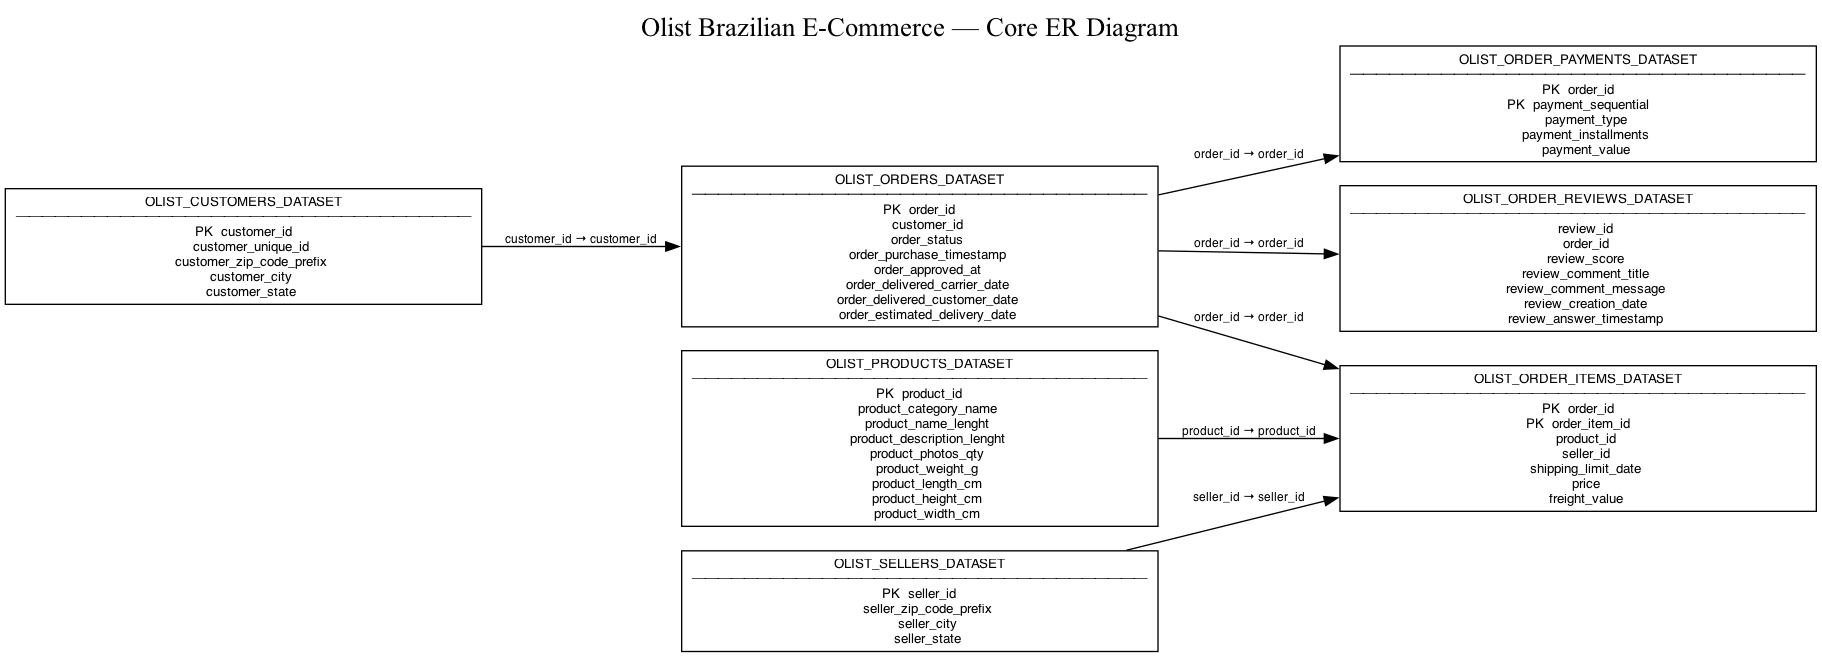

In [12]:
def format_table_label(table_name: str, df: pd.DataFrame) -> str:
    '''Create a readable Graphviz node label and mark detected primary keys.'''
    lines = [table_name.upper(), "─" * 35]
    lines.extend(
        f"{'PK  ' if column in confirmed_primary_keys.get(table_name, []) else '    '}{column}"
        for column in df.columns
    )
    return "\n".join(lines)


dot = Digraph("olist_er_diagram", format="png")
dot.attr(
    rankdir="LR",
    bgcolor="white",
    label="Olist Brazilian E-Commerce — Core ER Diagram",
    labelloc="t",
    fontsize="20",
)
dot.attr("node", shape="box", fontname="Helvetica", fontsize="10")
dot.attr("edge", fontname="Helvetica", fontsize="9")

for table_name in main_tables:
    dot.node(table_name, format_table_label(table_name, tables[table_name]))

for parent_table, parent_column, child_table, child_column in confirmed_relationships:
    dot.edge(parent_table, child_table, label=f"{parent_column} → {child_column}")

diagram_path = dot.render("olist_er_diagram", cleanup=True)
print(f"ER diagram written to: {diagram_path}")
display(Image(filename=diagram_path))


## 6. Generate a PostgreSQL DDL draft

This produces a *draft* schema from pandas types. Timestamp parsing, field lengths,
check constraints, and business-level constraints still need deliberate modelling before
production use. Only the explicitly confirmed keys from the preceding section are
included; detection results alone never become DDL constraints.


In [13]:
def postgres_type(series: pd.Series) -> str:
    '''Map common pandas dtypes to conservative PostgreSQL types.'''
    if pd.api.types.is_bool_dtype(series):
        return "BOOLEAN"
    if pd.api.types.is_integer_dtype(series):
        return "BIGINT"
    if pd.api.types.is_float_dtype(series):
        return "NUMERIC"
    if pd.api.types.is_datetime64_any_dtype(series):
        return "TIMESTAMP"
    return "TEXT"


def create_table_ddl(table_name: str, df: pd.DataFrame) -> str:
    '''Create readable PostgreSQL DDL with nullability and detected primary keys.'''
    definitions = []
    for column in df.columns:
        nullability = "NOT NULL" if df[column].notna().all() else "NULL"
        definitions.append(f'    "{column}" {postgres_type(df[column])} {nullability}')

    keys = confirmed_primary_keys.get(table_name, [])
    if keys:
        quoted_keys = ", ".join(f'"{key}"' for key in keys)
        definitions.append(f"    PRIMARY KEY ({quoted_keys})")

    return f'CREATE TABLE "{table_name}" (\n' + ",\n".join(definitions) + "\n);"


for table_name in main_tables:
    print(create_table_ddl(table_name, tables[table_name]))
    print()


CREATE TABLE "olist_customers_dataset" (
    "customer_id" TEXT NOT NULL,
    "customer_unique_id" TEXT NOT NULL,
    "customer_zip_code_prefix" BIGINT NOT NULL,
    "customer_city" TEXT NOT NULL,
    "customer_state" TEXT NOT NULL,
    PRIMARY KEY ("customer_id")
);

CREATE TABLE "olist_order_items_dataset" (
    "order_id" TEXT NOT NULL,
    "order_item_id" BIGINT NOT NULL,
    "product_id" TEXT NOT NULL,
    "seller_id" TEXT NOT NULL,
    "shipping_limit_date" TEXT NOT NULL,
    "price" NUMERIC NOT NULL,
    "freight_value" NUMERIC NOT NULL,
    PRIMARY KEY ("order_id", "order_item_id")
);

CREATE TABLE "olist_order_payments_dataset" (
    "order_id" TEXT NOT NULL,
    "payment_sequential" BIGINT NOT NULL,
    "payment_type" TEXT NOT NULL,
    "payment_installments" BIGINT NOT NULL,
    "payment_value" NUMERIC NOT NULL,
    PRIMARY KEY ("order_id", "payment_sequential")
);

CREATE TABLE "olist_order_reviews_dataset" (
    "review_id" TEXT NOT NULL,
    "order_id" TEXT NOT NULL,
    

## 7. validate a PostgreSQL load

This section assumes your database contains cleaned tables named `customers`, `orders`,
`order_items`, `products`, `sellers`, `order_payments`, and `order_reviews`. Leave
`CONNECT_TO_POSTGRES` as `False` to skip all database activity. Prefer a `DATABASE_URL`
environment variable so credentials are not stored in the notebook.


In [14]:
from sqlalchemy import create_engine, text
import os

CONNECT_TO_POSTGRES = True

# Set DATABASE_URL in your environment; this default matches a typical local setup.
DATABASE_URL = os.environ.get(
    "DATABASE_URL", "postgresql+psycopg2://localhost:5432/olist_db"
)

engine = create_engine(DATABASE_URL, pool_pre_ping=True) if CONNECT_TO_POSTGRES else None

if engine is not None:
    with engine.connect() as connection:
        database_version = connection.execute(text("SELECT version()")).scalar_one()
    print(database_version)
else:
    print("Skipped: PostgreSQL validation is disabled.")

PostgreSQL 15.18 (Homebrew) on aarch64-apple-darwin24.6.0, compiled by Apple clang version 17.0.0 (clang-1700.6.4.2), 64-bit


In [15]:
def run_sql(query: str) -> pd.DataFrame:
    '''Run a read-only query after the optional PostgreSQL connection has been enabled.'''
    if engine is None:
        raise RuntimeError("Enable CONNECT_TO_POSTGRES in the previous cell first.")
    return pd.read_sql(text(query), engine)


# Inspect the tables present in the target database.
if engine is None:
    print("Skipped: PostgreSQL validation is disabled.")
else:
    database_tables = run_sql('''
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public'
        ORDER BY table_name;
    ''')
    display(database_tables)


,table_name
0,category_translation
1,customers
2,geolocation
3,order_items
4,order_payments
5,order_reviews
6,orders
7,products
8,sellers


In [16]:
# Compare expected row counts after loading the seven core tables.
if engine is None:
    print("Skipped: PostgreSQL validation is disabled.")
else:
    row_counts = run_sql('''
        SELECT 'customers' AS table_name, COUNT(*) AS row_count FROM customers
        UNION ALL SELECT 'orders', COUNT(*) FROM orders
        UNION ALL SELECT 'order_items', COUNT(*) FROM order_items
        UNION ALL SELECT 'products', COUNT(*) FROM products
        UNION ALL SELECT 'sellers', COUNT(*) FROM sellers
        UNION ALL SELECT 'order_payments', COUNT(*) FROM order_payments
        UNION ALL SELECT 'order_reviews', COUNT(*) FROM order_reviews
        ORDER BY table_name;
    ''')
    display(row_counts)


,table_name,row_count
0,customers,99441
1,order_items,112650
2,order_payments,103886
3,order_reviews,99224
4,orders,99441
5,products,32951
6,sellers,3095


In [17]:
# Example business checks: customer distribution and join completeness.
if engine is None:
    print("Skipped: PostgreSQL validation is disabled.")
else:
    customer_states = run_sql('''
        SELECT customer_state, COUNT(*) AS customer_count
        FROM customers
        GROUP BY customer_state
        ORDER BY customer_count DESC;
    ''')
    display(customer_states)

    join_check = run_sql('''
        SELECT
            COUNT(*) AS orders_with_customer,
            COUNT(*) FILTER (WHERE c.customer_id IS NULL) AS orders_without_customer
        FROM orders AS o
        LEFT JOIN customers AS c ON c.customer_id = o.customer_id;
    ''')
    display(join_check)


,customer_state,customer_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


,orders_with_customer,orders_without_customer
0,99441,0


## 8. Business analysis queries

Ad-hoc queries against the loaded PostgreSQL tables, grouped by subject area. All
queries go through `run_sql()` (defined in section 7) so they are skipped cleanly
if `CONNECT_TO_POSTGRES` is `False`.


### 8.1 Quick recheck

In [18]:
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name;
"""

run_sql(query)

,table_name
0,category_translation
1,customers
2,geolocation
3,order_items
4,order_payments
5,order_reviews
6,orders
7,products
8,sellers


In [19]:
db_tables = [
    "customers",
    "orders",
    "order_items",
    "order_payments",
    "order_reviews",
    "products",
    "sellers",
    "geolocation",
]

for table in db_tables:
    query = f"SELECT COUNT(*) AS rows FROM {table};"
    count = run_sql(query).iloc[0, 0]
    print(f"{table}: {count:,} rows")

customers: 99,441 rows
orders: 99,441 rows
order_items: 112,650 rows
order_payments: 103,886 rows
order_reviews: 99,224 rows
products: 32,951 rows
sellers: 3,095 rows
geolocation: 1,000,163 rows


### 8.2 Orders

In [20]:
query = """
SELECT *
FROM orders
LIMIT 10;
"""

run_sql(query)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23


In [21]:
query = """
SELECT 
    order_status,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;
"""

order_status_counts = run_sql(query)
order_status_counts

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


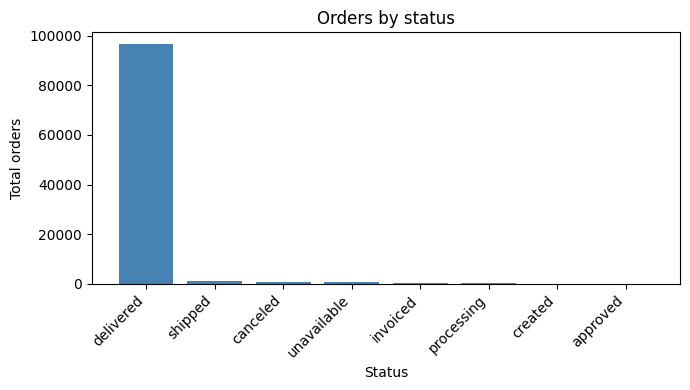

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(order_status_counts["order_status"], order_status_counts["total_orders"], color="steelblue")
ax.set_title("Orders by status")
ax.set_xlabel("Status")
ax.set_ylabel("Total orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
query = """
SELECT
    EXTRACT(YEAR FROM order_purchase_timestamp) AS year,
    COUNT(*) AS total_orders
FROM orders
GROUP BY year
ORDER BY year;
"""

orders_by_year = run_sql(query)
orders_by_year

,year,total_orders
0,2016.0,329
1,2017.0,45101
2,2018.0,54011


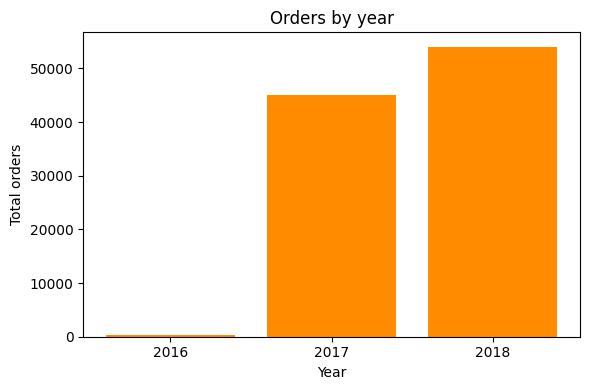

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(orders_by_year["year"].astype(int).astype(str), orders_by_year["total_orders"], color="darkorange")
ax.set_title("Orders by year")
ax.set_xlabel("Year")
ax.set_ylabel("Total orders")
plt.tight_layout()
plt.show()

In [25]:
query = """
SELECT
    DATE_TRUNC('month', order_purchase_timestamp) AS month,
    COUNT(*) AS total_orders
FROM orders
GROUP BY month
ORDER BY month;
"""

monthly_orders = run_sql(query)
monthly_orders

,month,total_orders
0,2016-09-01,4
1,2016-10-01,324
2,2016-12-01,1
3,2017-01-01,800
4,2017-02-01,1780
5,2017-03-01,2682
6,2017-04-01,2404
7,2017-05-01,3700
8,2017-06-01,3245
9,2017-07-01,4026


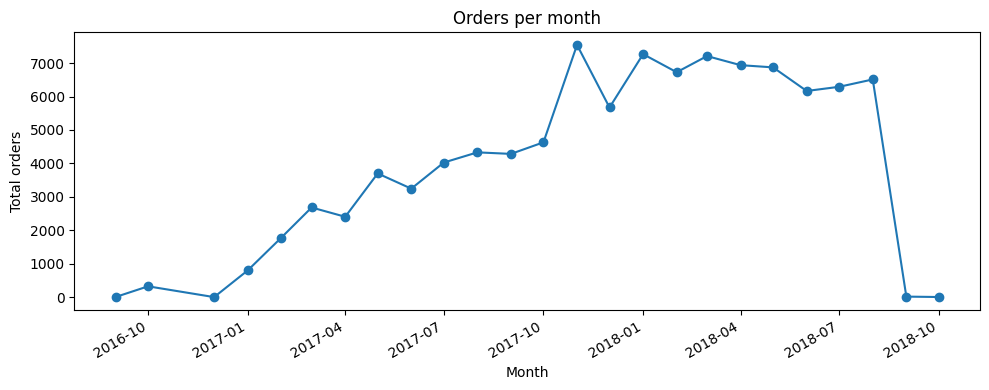

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_orders["month"], monthly_orders["total_orders"], marker="o")
ax.set_title("Orders per month")
ax.set_xlabel("Month")
ax.set_ylabel("Total orders")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 8.3 Customers

In [27]:
query = """
SELECT
    customer_state,
    COUNT(*) AS total_customers
FROM customers
GROUP BY customer_state
ORDER BY total_customers DESC;
"""

customer_state_counts = run_sql(query)
customer_state_counts

,customer_state,total_customers
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


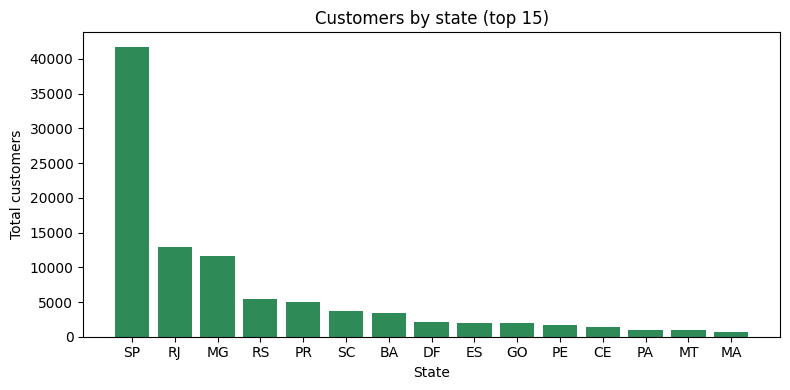

In [28]:
top_states = customer_state_counts.head(15)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(top_states["customer_state"], top_states["total_customers"], color="seagreen")
ax.set_title("Customers by state (top 15)")
ax.set_xlabel("State")
ax.set_ylabel("Total customers")
plt.tight_layout()
plt.show()

In [29]:
query = """
SELECT
    customer_city,
    customer_state,
    COUNT(*) AS total_customers
FROM customers
GROUP BY customer_city, customer_state
ORDER BY total_customers DESC
LIMIT 20;
"""

customer_city_counts = run_sql(query)
customer_city_counts

,customer_city,customer_state,total_customers
0,sao paulo,SP,15540
1,rio de janeiro,RJ,6882
2,belo horizonte,MG,2773
3,brasilia,DF,2131
4,curitiba,PR,1521
5,campinas,SP,1444
6,porto alegre,RS,1379
7,salvador,BA,1245
8,guarulhos,SP,1189
9,sao bernardo do campo,SP,938


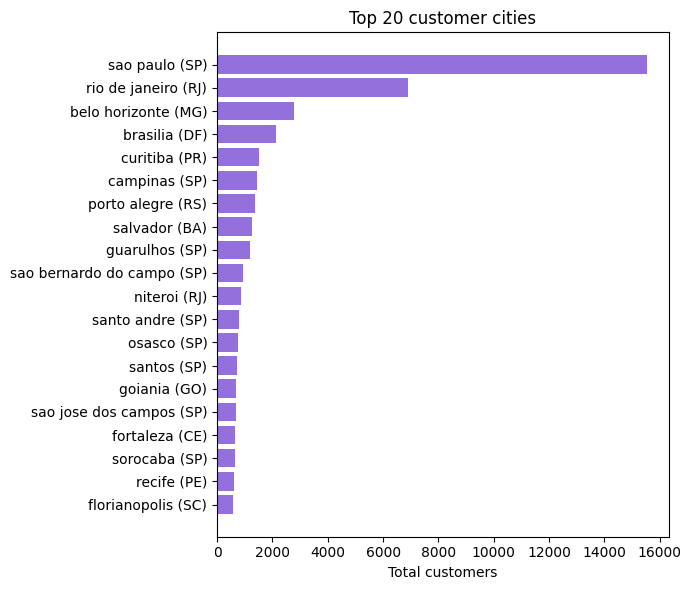

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
labels = customer_city_counts["customer_city"] + " (" + customer_city_counts["customer_state"] + ")"
ax.barh(labels[::-1], customer_city_counts["total_customers"][::-1], color="mediumpurple")
ax.set_title("Top 20 customer cities")
ax.set_xlabel("Total customers")
plt.tight_layout()
plt.show()

### 8.4 Products

In [31]:
query = """
SELECT *
FROM products
LIMIT 10;
"""

run_sql(query)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1,225,16,10,14
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44,276,1,1000,30,18,20
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46,250,1,154,18,9,15
3,cef67bcfe19066a932b7673e239eb23d,bebes,27,261,1,371,26,4,26
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37,402,4,625,20,17,13
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60,745,1,200,38,5,11
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56,1272,4,18350,70,24,44
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56,184,2,900,40,8,40
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57,163,1,400,27,13,17
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36,1156,1,600,17,10,12


In [32]:
query = """
SELECT
    product_category_name,
    COUNT(*) AS total_products
FROM products
GROUP BY product_category_name
ORDER BY total_products DESC;
"""

product_category_counts = run_sql(query)
product_category_counts

,product_category_name,total_products
0,cama_mesa_banho,3029
1,esporte_lazer,2867
2,moveis_decoracao,2657
3,beleza_saude,2444
4,utilidades_domesticas,2335
...,...,...
69,casa_conforto_2,5
70,fashion_roupa_infanto_juvenil,5
71,pc_gamer,3
72,seguros_e_servicos,2


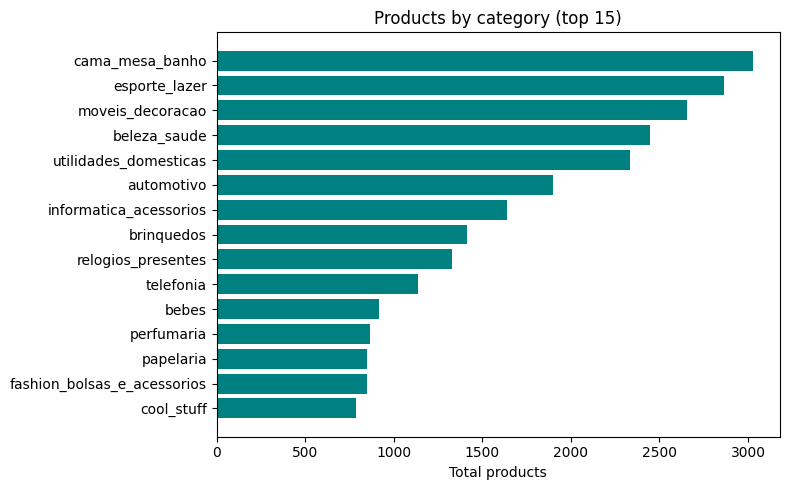

In [33]:
top_categories = product_category_counts.head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_categories["product_category_name"][::-1], top_categories["total_products"][::-1], color="teal")
ax.set_title("Products by category (top 15)")
ax.set_xlabel("Total products")
plt.tight_layout()
plt.show()

### 8.5 Sales & revenue

In [34]:
query = """
SELECT
    SUM(price) AS total_revenue,
    SUM(freight_value) AS total_freight
FROM order_items;
"""

run_sql(query)

,total_revenue,total_freight
0,13591643.7,2251909.54


In [35]:
query = """
SELECT
    product_id,
    COUNT(*) AS items_sold
FROM order_items
GROUP BY product_id
ORDER BY items_sold DESC
LIMIT 20;
"""

run_sql(query)

,product_id,items_sold
0,aca2eb7d00ea1a7b8ebd4e68314663af,527
1,99a4788cb24856965c36a24e339b6058,488
2,422879e10f46682990de24d770e7f83d,484
3,389d119b48cf3043d311335e499d9c6b,392
4,368c6c730842d78016ad823897a372db,388
5,53759a2ecddad2bb87a079a1f1519f73,373
6,d1c427060a0f73f6b889a5c7c61f2ac4,343
7,53b36df67ebb7c41585e8d54d6772e08,323
8,154e7e31ebfa092203795c972e5804a6,281
9,3dd2a17168ec895c781a9191c1e95ad7,274


In [36]:
query = """
SELECT
    p.product_category_name,
    COUNT(*) AS items_sold,
    SUM(oi.price) AS revenue
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY revenue DESC;
"""

category_revenue = run_sql(query)
category_revenue

,product_category_name,items_sold,revenue
0,beleza_saude,9670,1258681.34
1,relogios_presentes,5991,1205005.68
2,cama_mesa_banho,11115,1036988.68
3,esporte_lazer,8641,988048.97
4,informatica_acessorios,7827,911954.32
...,...,...,...
69,flores,33,1110.04
70,casa_conforto_2,30,760.27
71,cds_dvds_musicais,14,730.00
72,fashion_roupa_infanto_juvenil,8,569.85


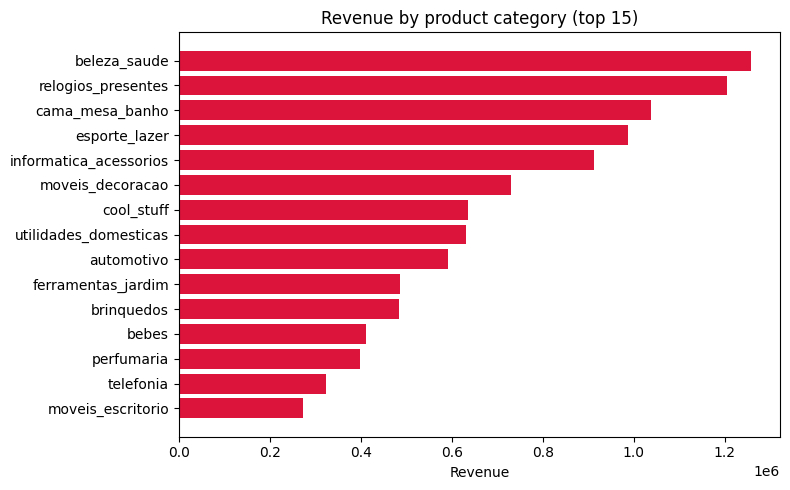

In [37]:
top_revenue_categories = category_revenue.head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_revenue_categories["product_category_name"][::-1], top_revenue_categories["revenue"][::-1], color="crimson")
ax.set_title("Revenue by product category (top 15)")
ax.set_xlabel("Revenue")
plt.tight_layout()
plt.show()

### 8.6 Payments

In [38]:
query = """
SELECT
    payment_type,
    COUNT(*) AS transactions,
    SUM(payment_value) AS total_value,
    AVG(payment_value) AS average_value
FROM order_payments
GROUP BY payment_type
ORDER BY total_value DESC;
"""

payment_type_summary = run_sql(query)
payment_type_summary

,payment_type,transactions,total_value,average_value
0,credit_card,76795,12542084.19,163.319021
1,boleto,19784,2869361.27,145.034435
2,voucher,5775,379436.87,65.703354
3,debit_card,1529,217989.79,142.570170
4,not_defined,3,0.00,0.000000


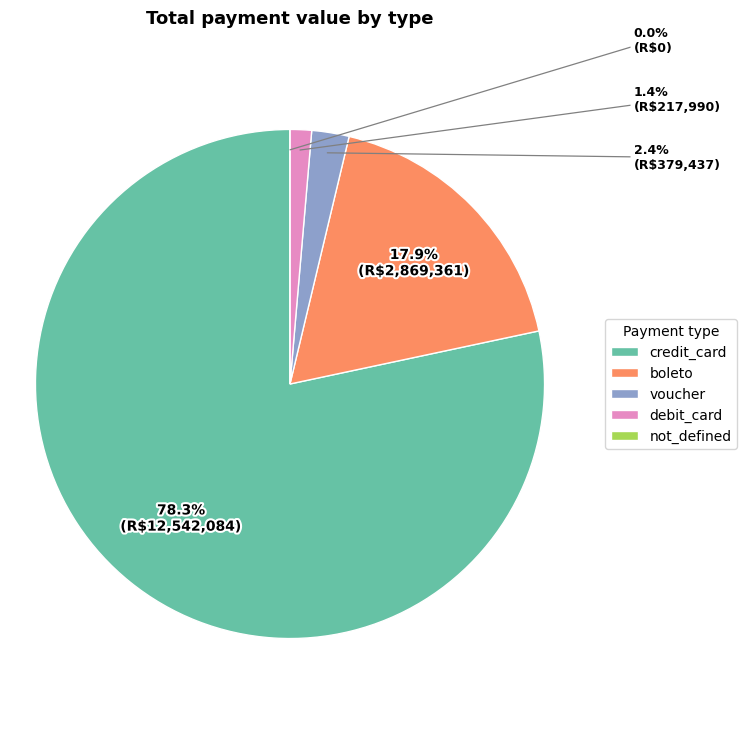

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

# Sort payment types
payment_type_sorted = (
    payment_type_summary
    .sort_values("total_value", ascending=False)
    .reset_index(drop=True)
)

colors = plt.cm.Set2.colors[:len(payment_type_sorted)]

total = payment_type_sorted["total_value"].sum()
pcts = payment_type_sorted["total_value"] / total * 100

SMALL_SLICE_THRESHOLD = 5

# ---------------------------------------------------------
# PIE CHART
# ---------------------------------------------------------

wedges, _ = ax.pie(
    payment_type_sorted["total_value"],
    labels=None,
    startangle=90,
    colors=colors,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1
    }
)

# ---------------------------------------------------------
# COLLECT LABEL INFORMATION
# ---------------------------------------------------------

left_labels = []
right_labels = []

for wedge, pct, value, payment_type in zip(
    wedges,
    pcts,
    payment_type_sorted["total_value"],
    payment_type_sorted["payment_type"]
):

    angle = np.radians((wedge.theta2 + wedge.theta1) / 2)

    x = np.cos(angle)
    y = np.sin(angle)

    label = f"{pct:.1f}%\n(R${value:,.0f})"

    # -----------------------------------------------------
    # SMALL SLICES → OUTSIDE LABEL
    # -----------------------------------------------------

    if pct < SMALL_SLICE_THRESHOLD:

        side = "right" if x >= 0 else "left"

        item = {
            "x": x,
            "y": y,
            "label": label,
            "pct": pct,
            "value": value,
            "payment_type": payment_type,
            "side": side
        }

        if side == "right":
            right_labels.append(item)
        else:
            left_labels.append(item)

    # -----------------------------------------------------
    # LARGE SLICES → INSIDE LABEL
    # -----------------------------------------------------

    else:

        ax.text(
            x * 0.68,
            y * 0.68,
            label,
            ha="center",
            va="center",
            fontsize=10,
            weight="bold",
            color="black",
            path_effects=[
                pe.withStroke(
                    linewidth=3,
                    foreground="white"
                )
            ]
        )


# ---------------------------------------------------------
# FUNCTION TO PREVENT OVERLAPPING LABELS
# ---------------------------------------------------------

def adjust_labels(labels, min_y_diff=0.22):

    if not labels:
        return labels

    # Sort from bottom → top
    labels = sorted(labels, key=lambda item: item["y"])

    # Initial positions
    for item in labels:
        item["y_text"] = item["y"] * 1.25

    # Push labels apart
    for i in range(1, len(labels)):

        previous = labels[i - 1]
        current = labels[i]

        if current["y_text"] - previous["y_text"] < min_y_diff:

            current["y_text"] = (
                previous["y_text"] + min_y_diff
            )

    # Keep labels inside a reasonable range
    MAX_Y = 1.35
    MIN_Y = -1.35

    # If top labels go too high, shift everything down
    if labels[-1]["y_text"] > MAX_Y:

        shift = labels[-1]["y_text"] - MAX_Y

        for item in labels:
            item["y_text"] -= shift

    # If bottom labels go too low, shift everything up
    if labels[0]["y_text"] < MIN_Y:

        shift = MIN_Y - labels[0]["y_text"]

        for item in labels:
            item["y_text"] += shift

    return labels


# ---------------------------------------------------------
# ADJUST BOTH SIDES
# ---------------------------------------------------------

right_labels = adjust_labels(
    right_labels,
    min_y_diff=0.23
)

left_labels = adjust_labels(
    left_labels,
    min_y_diff=0.23
)


# ---------------------------------------------------------
# DRAW OUTSIDE LABELS
# ---------------------------------------------------------

def draw_outside_labels(labels):

    for item in labels:

        x = item["x"]
        y = item["y"]

        # Fixed X position for clean columns
        x_text = 1.35 if item["side"] == "right" else -1.35

        ha = "left" if item["side"] == "right" else "right"

        ax.annotate(
            item["label"],

            # Arrow starts near the pie
            xy=(x * 0.92, y * 0.92),

            # Text position
            xytext=(x_text, item["y_text"]),

            ha=ha,
            va="center",

            fontsize=9,
            weight="bold",

            arrowprops=dict(
                arrowstyle="-",
                color="gray",
                lw=0.9,
                shrinkA=0,
                shrinkB=0
            ),

            # White background prevents text collision
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="none",
                alpha=0.85
            )
        )


draw_outside_labels(right_labels)
draw_outside_labels(left_labels)


# ---------------------------------------------------------
# TITLE
# ---------------------------------------------------------

ax.set_title(
    "Total payment value by type",
    fontsize=13,
    weight="bold",
    pad=15
)


# ---------------------------------------------------------
# LEGEND
# ---------------------------------------------------------

ax.legend(
    wedges,
    payment_type_sorted["payment_type"],
    title="Payment type",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5)
)

ax.axis("equal")

# Give more room around the chart
plt.subplots_adjust(
    left=0.05,
    right=0.75,
    top=0.90,
    bottom=0.05
)

plt.show()

In [40]:
query = """
SELECT
    payment_installments,
    COUNT(*) AS transactions
FROM order_payments
GROUP BY payment_installments
ORDER BY payment_installments;
"""

payment_installments_counts = run_sql(query)
payment_installments_counts

,payment_installments,transactions
0,0,2
1,1,52546
2,2,12413
3,3,10461
4,4,7098
5,5,5239
6,6,3920
7,7,1626
8,8,4268
9,9,644


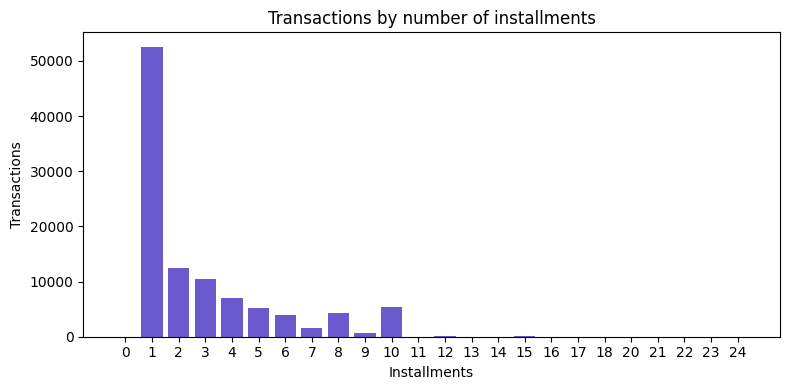

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(payment_installments_counts["payment_installments"].astype(str), payment_installments_counts["transactions"], color="slateblue")
ax.set_title("Transactions by number of installments")
ax.set_xlabel("Installments")
ax.set_ylabel("Transactions")
plt.tight_layout()
plt.show()

### 8.7 Reviews

In [42]:
query = """
SELECT
    review_score,
    COUNT(*) AS total_reviews
FROM order_reviews
GROUP BY review_score
ORDER BY review_score;
"""

review_scores = run_sql(query)
review_scores

,review_score,total_reviews
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


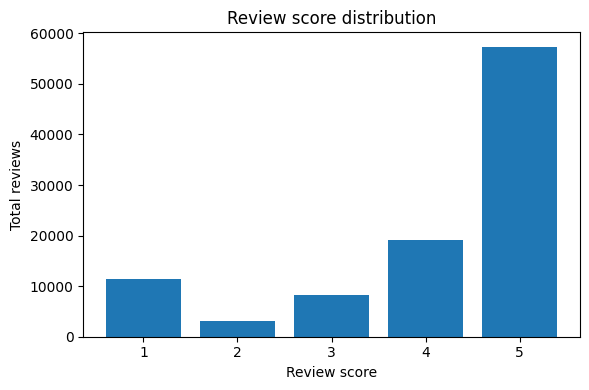

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(review_scores["review_score"].astype(str), review_scores["total_reviews"])
ax.set_title("Review score distribution")
ax.set_xlabel("Review score")
ax.set_ylabel("Total reviews")
plt.tight_layout()
plt.show()

In [44]:
query = """
SELECT
    AVG(review_score) AS average_review_score
FROM order_reviews;
"""

run_sql(query)

,average_review_score
0,4.086421


### 8.8 Joined views

In [45]:
query = """
SELECT
    o.order_id,
    o.order_status,
    o.order_purchase_timestamp,
    c.customer_city,
    c.customer_state
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
LIMIT 20;
"""

run_sql(query)

,order_id,order_status,order_purchase_timestamp,customer_city,customer_state
0,5f79b5b0931d63f1a42989eb65b9da6e,delivered,2017-11-14 16:08:26,osasco,SP
1,a44895d095d7e0702b6a162fa2dbeced,delivered,2017-07-16 09:40:32,itapecerica,MG
2,316a104623542e4d75189bb372bc5f8d,delivered,2017-02-28 11:06:43,nova venecia,ES
3,5825ce2e88d5346438686b0bba99e5ee,delivered,2017-08-16 13:09:20,mendonca,MG
4,0ab7fb08086d4af9141453c91878ed7a,delivered,2018-04-02 13:42:17,sao paulo,SP
5,cd3558a10d854487b4f907e9b326a4fc,delivered,2017-04-12 08:35:12,valinhos,SP
6,07f6c3baf9ac86865b60f640c4f923c6,delivered,2018-03-02 17:47:40,niteroi,RJ
7,8c3d752c5c02227878fae49aeaddbfd7,delivered,2017-12-18 11:08:30,rio de janeiro,RJ
8,fa906f338cee30a984d0945b3832e431,delivered,2017-09-17 16:04:44,ijui,RS
9,9b961b894e797f63622137ff7eb1c1af,delivered,2018-08-11 12:14:35,oliveira,MG


In [46]:
query = """
SELECT
    o.order_id,
    o.order_status,
    oi.product_id,
    oi.price,
    oi.freight_value
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
LIMIT 20;
"""

run_sql(query)

,order_id,order_status,product_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,delivered,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,delivered,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,delivered,7634da152a4610f1595efa32f14722fc,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,delivered,ac6c3623068f30de03045865e4e10089,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,delivered,ef92defde845ab8450f9d70c526ef70f,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,delivered,8d4f2bb7e93e6710a28f34fa83ee7d28,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,delivered,557d850972a7d6f792fd18ae1400d9b6,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,delivered,310ae3c140ff94b03219ad0adc3c778f,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,delivered,4535b0e1091c278dfd193e5a1d63b39f,53.99,11.40


In [47]:
query = """
SELECT
    oi.order_id,
    oi.product_id,
    p.product_category_name,
    oi.price
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
LIMIT 20;
"""

run_sql(query)

,order_id,product_id,product_category_name,price
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.90
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,239.90
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,199.00
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,199.90
5,00048cc3ae777c65dbb7d2a0634bc1ea,ef92defde845ab8450f9d70c526ef70f,utilidades_domesticas,21.90
6,00054e8431b9d7675808bcb819fb4a32,8d4f2bb7e93e6710a28f34fa83ee7d28,telefonia,19.90
7,000576fe39319847cbb9d288c5617fa6,557d850972a7d6f792fd18ae1400d9b6,ferramentas_jardim,810.00
8,0005a1a1728c9d785b8e2b08b904576c,310ae3c140ff94b03219ad0adc3c778f,beleza_saude,145.95
9,0005f50442cb953dcd1d21e1fb923495,4535b0e1091c278dfd193e5a1d63b39f,livros_tecnicos,53.99


In [48]:
query = """
SELECT
    order_id,
    SUM(price) AS total_price,
    SUM(freight_value) AS total_freight,
    COUNT(*) AS number_of_items
FROM order_items
GROUP BY order_id
ORDER BY total_price DESC
LIMIT 20;
"""

run_sql(query)

,order_id,total_price,total_freight,number_of_items
0,03caa2c082116e1d31e67e9ae3700499,13440.00,224.08,8
1,736e1922ae60d0d6a89247b851902527,7160.00,114.88,4
2,0812eb902a67711a1cb742b3cdaa65ae,6735.00,194.31,1
3,fefacc66af859508bf1a7934eab1e97f,6729.00,193.21,1
4,f5136e38d1a14a4dbd87dff67da82701,6499.00,227.66,1
5,2cc9089445046817a7539d90805e6e5a,5934.60,146.94,6
6,a96610ab360d42a2e5335a3998b4718a,4799.00,151.34,1
7,199af31afc78c699f0dbf71fb178d4d4,4690.00,74.34,1
8,b4c4b76c642808cbe472a32b86cddc95,4599.90,209.54,2
9,8dbc85d1447242f3b127dda390d56e19,4590.00,91.78,1


In [49]:
query = """
SELECT
    o.order_id,
    o.order_status,
    o.order_purchase_timestamp,
    c.customer_state,
    COUNT(oi.product_id) AS number_of_items,
    SUM(oi.price) AS total_price,
    SUM(oi.freight_value) AS total_freight

FROM orders o

JOIN customers c
    ON o.customer_id = c.customer_id

JOIN order_items oi
    ON o.order_id = oi.order_id

GROUP BY
    o.order_id,
    o.order_status,
    o.order_purchase_timestamp,
    c.customer_state

LIMIT 20;
"""

run_sql(query)

,order_id,order_status,order_purchase_timestamp,customer_state,number_of_items,total_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,2017-09-13 08:59:02,RJ,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,delivered,2017-04-26 10:53:06,SP,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,delivered,2018-01-14 14:33:31,MG,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,delivered,2018-08-08 10:00:35,SP,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,delivered,2017-02-04 13:57:51,SP,1,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,delivered,2017-05-15 21:42:34,MG,1,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,delivered,2017-12-10 11:53:48,SP,1,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,delivered,2018-07-04 12:08:27,SP,1,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,delivered,2018-03-19 18:40:33,SP,1,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,delivered,2018-07-02 13:59:39,SP,1,53.99,11.40


### 8.9 Delivery performance

The late-delivery flag is defined once in a CTE below and reused across the next
three queries instead of repeating the same `CASE WHEN` three times.


In [50]:
late_delivery_cte = """
WITH delivery AS (
    SELECT
        order_id,
        order_purchase_timestamp,
        order_estimated_delivery_date,
        order_delivered_customer_date,
        CASE
            WHEN order_delivered_customer_date > order_estimated_delivery_date
            THEN 1
            ELSE 0
        END AS late_delivery
    FROM orders
    WHERE order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
)
"""

query = late_delivery_cte + """
SELECT
    order_id,
    order_purchase_timestamp,
    order_estimated_delivery_date,
    order_delivered_customer_date,
    late_delivery
FROM delivery
LIMIT 20;
"""

run_sql(query)

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-18,2017-10-10 21:25:13,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-13,2018-08-07 15:27:45,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-09-04,2018-08-17 18:06:29,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-15,2017-12-02 00:28:42,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-26,2018-02-16 18:17:02,0
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,2017-08-01,2017-07-26 10:57:55,0
6,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,2017-06-07,2017-05-26 12:55:51,0
7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,2017-03-06,2017-02-02 14:08:10,0
8,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,2017-08-23,2017-08-16 17:14:30,0
9,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-16 19:41:10,2017-06-07,2017-05-29 11:18:31,0


In [51]:
query = late_delivery_cte + """
SELECT
    CASE WHEN late_delivery = 1 THEN 'Late' ELSE 'On Time' END AS delivery_status,
    COUNT(*) AS total_orders
FROM delivery
GROUP BY delivery_status;
"""

delivery_status_counts = run_sql(query)
delivery_status_counts

,delivery_status,total_orders
0,On Time,88649
1,Late,7827


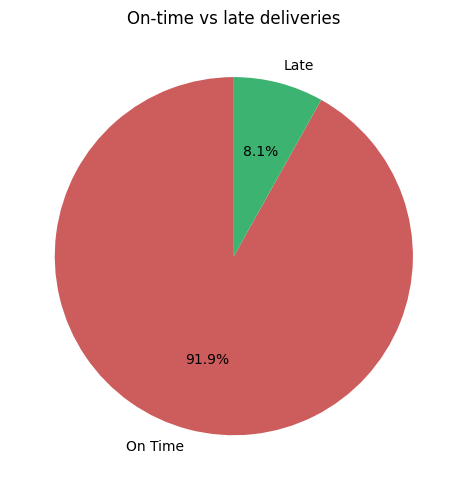

In [52]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    delivery_status_counts["total_orders"],
    labels=delivery_status_counts["delivery_status"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["indianred", "mediumseagreen"],
)
ax.set_title("On-time vs late deliveries")
plt.tight_layout()
plt.show()

In [53]:
query = late_delivery_cte + """
SELECT
    ROUND(100.0 * SUM(late_delivery) / COUNT(*), 2) AS late_delivery_percentage
FROM delivery;
"""

run_sql(query)

,late_delivery_percentage
0,8.11


## 9. Summary

- Core entities: `customers`, `orders`, `order_items`, `products`, `sellers`,
  `order_payments`, with `orders.order_id` as the central business key.
- Section 8 covers order volume/status, customer geography, product mix,
  revenue, payment behavior, review scores, and delivery performance.
- The late-delivery rate computed in 8.9 is the headline delivery KPI; re-run
  section 8 after each data refresh to track it over time.
